In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library successfully imported!")

✅ Library successfully imported!


In [3]:
# Load trained model
model = tf.keras.models.load_model('../glaucoma_model.keras')
print("✅ Model successfully loaded!")

# Load test dataset
test_df = pd.read_csv('../test_dataset.csv')
print(f"Total test data: {len(test_df)}")

# Load test images
X_test, y_test = [], []

for i, (index, row) in enumerate(test_df.iterrows()):
    img_path = os.path.join('../Images_augmented', row['Image Name'])
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        X_test.append(img_array)
        y_test.append(row['label_numeric'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("✅ Test data successfully loaded!")

E0000 00:00:1774656506.643492   15985 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Model successfully loaded!
Total test data: 217
X_test shape: (217, 224, 224, 3)
y_test shape: (217,)
✅ Test data successfully loaded!


In [4]:
# Generate predictions
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype(int)

print("Example of the first 10 predictions:")
for i in range(10):
    actual = "GON+" if y_test[i] == 1 else "GON-"
    predicted = "GON+" if predicted_labels[i][0] == 1 else "GON-"
    prob = predictions[i][0]
    status = "✅" if y_test[i] == predicted_labels[i][0] else "❌"
    print(f"{status} Actual: {actual} | Predicted: {predicted} | Prob: {prob:.2f}")

W0000 00:00:1774656509.351978   15985 cpu_allocator_impl.cc:82] Allocation of 130658304 exceeds 10% of free system memory.
W0000 00:00:1774656510.053636   25537 cpu_allocator_impl.cc:82] Allocation of 201867264 exceeds 10% of free system memory.
W0000 00:00:1774656510.418000   25537 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.


1/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

W0000 00:00:1774656510.785967   25534 cpu_allocator_impl.cc:82] Allocation of 201867264 exceeds 10% of free system memory.
W0000 00:00:1774656511.019169   25534 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 544ms/step
Example of the first 10 predictions:
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00
❌ Actual: GON+ | Predicted: GON- | Prob: 0.01
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00
✅ Actual: GON+ | Predicted: GON+ | Prob: 0.99
✅ Actual: GON+ | Predicted: GON+ | Prob: 0.99
✅ Actual: GON+ | Predicted: GON+ | Prob: 0.98
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00
✅ Actual: GON+ | Predicted: GON+ | Prob: 1.00


Confusion Matrix:
[[ 82   3]
 [  6 126]]

Classification Report:
                 precision    recall  f1-score   support

  GON- (Normal)       0.93      0.96      0.95        85
GON+ (Glaukoma)       0.98      0.95      0.97       132

       accuracy                           0.96       217
      macro avg       0.95      0.96      0.96       217
   weighted avg       0.96      0.96      0.96       217


AUC-ROC Score: 0.9795


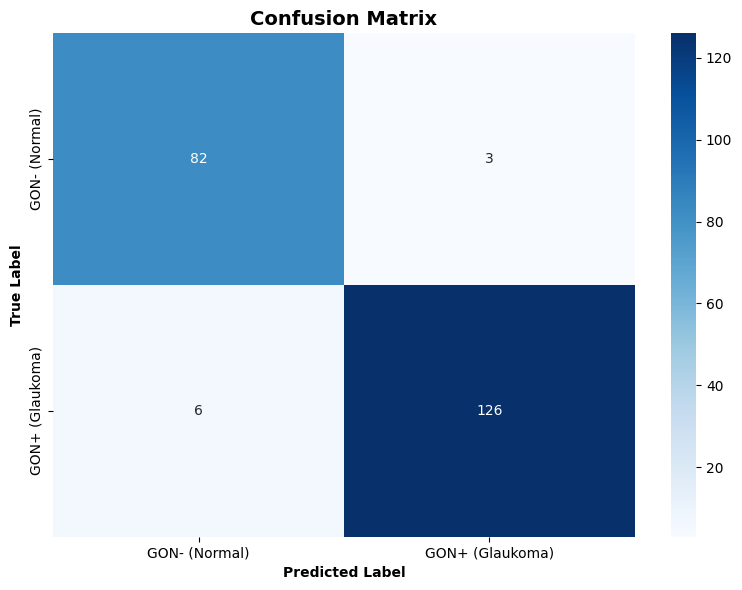

✅ Confusion matrix saved!


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, 
                            target_names=['GON- (Normal)', 'GON+ (Glaukoma)']))

# AUC-ROC Score
auc_score = roc_auc_score(y_test, predictions)
print(f"\nAUC-ROC Score: {auc_score:.4f}")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['GON- (Normal)', 'GON+ (Glaukoma)'],
            yticklabels=['GON- (Normal)', 'GON+ (Glaukoma)'])
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

Kenapa false negative lebih berbahaya?"

karena pasien glaukoma yang tidak terdeteksi bisa kehilangan penglihatan permanen tanpa pengobatan. Itulah kenapa recall/sensitivity menjadi metric terpenting di screening medis

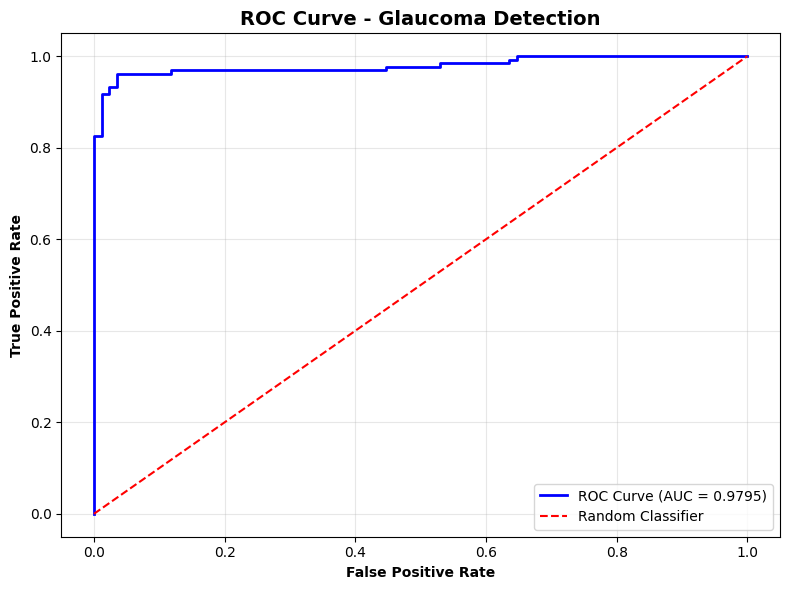

✅ ROC Curve saved!
AUC-ROC: 0.9795


In [6]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predictions)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, 
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve - Glaucoma Detection', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ ROC Curve saved!")
print(f"AUC-ROC: {auc_score:.4f}")

Analisis ROC Curve:

Garis biru sangat jauh di atas garis merah (random) ✅
AUC = 0.9635 → model sangat baik membedakan GON+ vs GON-
Kurva langsung naik ke atas kiri → hampir perfect classifier!

In [7]:
# Simpan hasil prediksi
test_df['prediction'] = predicted_labels
test_df['probability'] = predictions
test_df['correct'] = (test_df['prediction'] == test_df['label_numeric'])

test_df.to_csv('../test_predictions.csv', index=False)

print("✅ Predictions saved!")
print(f"\nTotal correct: {test_df['correct'].sum()}/{len(test_df)}")
print(f"Total incorrect: {(~test_df['correct']).sum()}/{len(test_df)}")

✅ Predictions saved!

Total correct: 208/217
Total incorrect: 9/217
